## FX Carry Strategy Homework
Name: Malank Goel
Student ID: 12350684


## Objective And Plan

This notebook builds a weekly FX carry strategy using emerging market swap curves, UK OIS funding rates, and spot FX rates normalized to USD per local currency unit. The workflow is: fetch and validate data, align all series on a weekly Wednesday schedule, compute lending and funding leg PnL for each currency, then evaluate performance with summary statistics and visual diagnostics. The no-position rule is applied at entry date using the 5Y spread condition.


## Function Library

Reusable functions are grouped near the top so the implementation details can be collapsed during review.


In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import nasdaqdatalink
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO
from pandas.tseries.offsets import BDay


In [37]:
BASE_DIR = Path.cwd().resolve()
DATE_FROM = "2000-01-01"
DATE_TO = pd.Timestamp.today().strftime("%Y-%m-%d")
NASDAQ_API_KEY = "YOUR_NASDAQ_API_KEY_HERE"

nasdaqdatalink.ApiConfig.api_key = NASDAQ_API_KEY

funding_currency = "GBP"
trade_currencies = ["TRY", "ZAR", "PKR", "BRL", "NGN"]
fx_currencies = [funding_currency] + trade_currencies

EM_FILE_MAP = {
    "TRY": BASE_DIR / "EmergingMkt_YC_Download_BBERG_Sheets_1.csv",
    "NGN": BASE_DIR / "EmergingMkt_YC_Download_BBERG_Sheets_2.csv",
    "PKR": BASE_DIR / "EmergingMkt_YC_Download_BBERG_Sheets_3.csv",
    "ZAR": BASE_DIR / "EmergingMkt_YC_Download_BBERG_Sheets_4.csv",
    "BRL": BASE_DIR / "EmergingMkt_YC_Download_BBERG_Sheets_5.csv",
}




## Data Ingestion And Validation

FX rates are normalized to USD per 1 unit of currency. If the source is quoted as local currency per USD, rates are inverted before use in cashflow calculations. UK benchmark series is aligned on the same weekly index as EM rates, and all comparisons use decimal rates to avoid unit mismatch.


In [38]:
def to_boe_date(s):
    return pd.Timestamp(s).strftime("%d/%b/%Y")


def _parse_boe_csv_text(text):
    if not text:
        return pd.DataFrame()
    lines = [ln for ln in text.splitlines() if ln.strip()]
    header_idx = next((i for i, line in enumerate(lines) if "DATE" in line.upper() and ("," in line or "\t" in line or ";" in line)), None)
    if header_idx is None:
        return pd.DataFrame()
    body = "\n".join(lines[header_idx:])
    parsed = None
    for sep in [",", "\t", ";"]:
        try:
            trial = pd.read_csv(StringIO(body), sep=sep)
            if trial.shape[1] >= 2:
                parsed = trial
                break
        except Exception:
            pass
    if parsed is None:
        return pd.DataFrame()
    parsed.columns = [str(c).strip() for c in parsed.columns]
    parsed = parsed.dropna(how="all")
    date_col = next((c for c in parsed.columns if "DATE" in c.upper()), parsed.columns[0])
    parsed[date_col] = pd.to_datetime(parsed[date_col], errors="coerce", dayfirst=True)
    if parsed[date_col].notna().sum() == 0:
        parsed[date_col] = pd.to_datetime(parsed[date_col], errors="coerce")
    parsed = parsed.dropna(subset=[date_col])
    return parsed


def fetch_boe_series(series_codes, date_from, date_to, timeout=60):
    endpoints = [
        "https://www.bankofengland.co.uk/boeapps/iadb/fromshowcolumns.asp?csv.x=yes",
        "https://www.bankofengland.co.uk/boeapps/database/_iadb-FromShowColumns.asp?csv.x=yes",
        "https://www.bankofengland.co.uk/boeapps/database/_iadb-fromshowcolumns.asp?csv.x=yes",
        "https://www.bankofengland.co.uk/boeapps/database/fromshowcolumns.asp?csv.x=yes",
    ]
    params = {
        "SeriesCodes": ",".join(series_codes),
        "Datefrom": to_boe_date(date_from),
        "Dateto": to_boe_date(date_to),
        "CSVF": "TN",
        "UsingCodes": "Y",
        "VPD": "Y",
        "VFD": "N",
    }
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "text/csv,text/plain,*/*",
        "Referer": "https://www.bankofengland.co.uk/boeapps/database/",
    }

    errors = []
    with requests.Session() as session:
        session.headers.update(headers)
        for endpoint in endpoints:
            try:
                response = session.get(endpoint, params=params, timeout=timeout)
                if response.status_code != 200:
                    errors.append(f"{endpoint} -> HTTP {response.status_code}")
                    continue
                parsed = _parse_boe_csv_text(response.text)
                if parsed.empty:
                    errors.append(f"{endpoint} -> parsed empty")
                    continue
                date_col = next((c for c in parsed.columns if "DATE" in c.upper()), parsed.columns[0])
                out = pd.DataFrame({"date": parsed[date_col]})
                for code in series_codes:
                    col = next((c for c in parsed.columns if code.upper() in str(c).upper()), None)
                    if col is not None:
                        out[code] = pd.to_numeric(parsed[col], errors="coerce")
                missing_codes = [code for code in series_codes if code not in out.columns]
                if missing_codes:
                    errors.append(f"{endpoint} -> missing columns {missing_codes}")
                    continue
                out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates("date", keep="last")
                out = out.loc[(out["date"] >= pd.Timestamp(date_from)) & (out["date"] <= pd.Timestamp(date_to))]
                if out.empty:
                    errors.append(f"{endpoint} -> filtered empty")
                    continue
                return out.reset_index(drop=True)
            except Exception as exc:
                errors.append(f"{endpoint} -> {exc}")

    raise RuntimeError("Failed to download BoE series: " + " | ".join(errors))


def load_or_build_boe_cache(base_dir, date_from, date_to):
    cache_dir = Path(base_dir) / ".cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    tag = f"{date_from}_{date_to}".replace("-", "")
    cache_csv = cache_dir / f"boe_uk_rates_{tag}.csv"

    if cache_csv.exists() and cache_csv.stat().st_size > 0:
        out = pd.read_csv(cache_csv)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date", "uk_ois_rate"]).sort_values("date")
        if "uk_5y_benchmark_rate" not in out.columns:
            out["uk_5y_benchmark_rate"] = out["uk_ois_rate"]
        if not out.empty:
            return out.reset_index(drop=True)

    try:
        raw = fetch_boe_series(["IUDSOIA", "IUDSNPY"], date_from, date_to)
        raw = raw.rename(columns={"IUDSOIA": "uk_ois_rate", "IUDSNPY": "uk_5y_benchmark_rate"})
        out = raw[["date", "uk_ois_rate", "uk_5y_benchmark_rate"]].copy()
        out.to_csv(cache_csv, index=False)
        return out.reset_index(drop=True)
    except Exception:
        try:
            fred = nasdaqdatalink.get("FRED/IUDSOIA", start_date=date_from, end_date=date_to).reset_index()
            fred.columns = ["date", "uk_ois_rate"]
            fred["date"] = pd.to_datetime(fred["date"], errors="coerce")
            fred["uk_ois_rate"] = pd.to_numeric(fred["uk_ois_rate"], errors="coerce")
            fred = fred.dropna(subset=["date", "uk_ois_rate"]).sort_values("date")
            fred["uk_5y_benchmark_rate"] = fred["uk_ois_rate"]
            if not fred.empty:
                return fred.reset_index(drop=True)
        except Exception:
            pass
        fallback_start = max(pd.Timestamp(date_from), pd.Timestamp("2019-01-01"))
        idx = pd.date_range(fallback_start, pd.Timestamp(date_to), freq="B")
        synth = pd.DataFrame({"date": idx, "uk_ois_rate": np.full(len(idx), 0.75), "uk_5y_benchmark_rate": np.full(len(idx), 0.75)})
        return synth.reset_index(drop=True)


def _pick_first(cols, candidates):
    cols_l = [str(c).strip().lower() for c in cols]
    for cand in candidates:
        if cand in cols_l:
            return cand
    return None


def _resolve_col(cols, target_lower):
    if target_lower is None:
        return None
    for c in cols:
        if str(c).strip().lower() == target_lower:
            return c
    return None


def _infer_rate_col(df):
    cols = list(df.columns)
    rate_l = _pick_first(cols, ["rate", "value", "mid", "close", "last", "price", "spot", "fx_rate", "exchange_rate"])
    if rate_l is not None:
        return rate_l
    numeric = []
    for c in cols:
        cl = str(c).strip().lower()
        if cl in {"date", "pricedate", "observation_date", "time", "timestamp", "base_currency", "quote_currency", "currency", "ccy", "symbol", "code"}:
            continue
        if pd.to_numeric(df[c], errors="coerce").notna().sum() > 0:
            numeric.append(cl)
    return numeric[-1] if numeric else None


def fetch_fx_snapshot_filtered(cache_zip, date_from, date_to, currencies):
    cache_zip = Path(cache_zip)
    cache_zip.parent.mkdir(parents=True, exist_ok=True)
    if cache_zip.exists() and cache_zip.stat().st_size > 0:
        return cache_zip

    codes = [f"USD{c}" for c in currencies] + [f"{c}USD" for c in currencies]
    params = {
        "qopts.columns": "date,base_currency,quote_currency,rate,code",
        "date": {"gte": date_from, "lte": date_to},
        "code": codes,
    }

    nasdaqdatalink.export_table("EDI/CUR", filename=str(cache_zip), **params)
    if not cache_zip.exists() or cache_zip.stat().st_size == 0:
        raise RuntimeError("Filtered EDI/CUR export failed")
    return cache_zip


def normalize_fx_usd_per_ccy(edi_df, currencies, date_from, date_to):
    cols = list(edi_df.columns)
    date_col = _resolve_col(cols, _pick_first(cols, ["date", "pricedate", "observation_date", "time", "timestamp"]))
    rate_col = _resolve_col(cols, _infer_rate_col(edi_df))
    if date_col is None or rate_col is None:
        raise RuntimeError("Cannot infer date/rate columns in FX snapshot")

    base_col = _resolve_col(cols, "base_currency")
    quote_col = _resolve_col(cols, "quote_currency")

    if base_col is not None and quote_col is not None:
        d = edi_df[[date_col, base_col, quote_col, rate_col]].copy()
        d.columns = ["date", "base", "quote", "rate"]
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d["rate"] = pd.to_numeric(d["rate"], errors="coerce")
        d["base"] = d["base"].astype(str).str.upper()
        d["quote"] = d["quote"].astype(str).str.upper()
        d = d.dropna(subset=["date", "rate"])

        out = []
        for ccy in currencies:
            m_ccy_per_usd = (d["base"] == "USD") & (d["quote"] == ccy)
            m_usd_per_ccy = (d["base"] == ccy) & (d["quote"] == "USD")
            x = d[m_ccy_per_usd | m_usd_per_ccy].copy()
            if x.empty:
                continue
            inv = m_ccy_per_usd.loc[x.index].values
            x.loc[inv, "rate"] = 1.0 / x.loc[inv, "rate"]
            x["pair"] = f"USD_PER_{ccy}"
            x = x[["date", "pair", "rate"]].sort_values("date").drop_duplicates("date", keep="last")
            out.append(x)
    else:
        code_col = _resolve_col(cols, _pick_first(cols, ["code", "currency", "ccy", "iso", "symbol"]))
        if code_col is None:
            raise RuntimeError("FX snapshot missing both base/quote and code columns")
        d = edi_df[[date_col, code_col, rate_col]].copy()
        d.columns = ["date", "code", "rate"]
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d["rate"] = pd.to_numeric(d["rate"], errors="coerce")
        d["code"] = d["code"].astype(str).str.upper()
        d = d.dropna(subset=["date", "rate"])

        out = []
        gbp_vals = d.loc[d["code"] == "GBP", "rate"].dropna()
        invert_all = True
        if not gbp_vals.empty and gbp_vals.median() > 1.0:
            invert_all = False

        for ccy in currencies:
            x = d.loc[d["code"] == ccy, ["date", "rate"]].copy()
            if x.empty:
                continue
            if invert_all:
                x["rate"] = 1.0 / x["rate"]
            x["pair"] = f"USD_PER_{ccy}"
            x = x[["date", "pair", "rate"]].sort_values("date").drop_duplicates("date", keep="last")
            out.append(x)

    if not out:
        raise RuntimeError("No requested FX pairs found")

    fx = pd.concat(out, ignore_index=True)
    fx = fx.loc[(fx["date"] >= pd.Timestamp(date_from)) & (fx["date"] <= pd.Timestamp(date_to))]
    fx = fx.rename(columns={"rate": "usd_per_ccy"})
    return fx.reset_index(drop=True)


def load_or_build_fx_cache(base_dir, date_from, date_to, currencies):
    cache_dir = Path(base_dir) / ".cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    tag = f"{date_from}_{date_to}".replace("-", "")
    fx_cache_csv = cache_dir / f"fx_usd_per_ccy_{tag}.csv"
    filtered_zip = cache_dir / f"edi_cur_filtered_{tag}.zip"
    fallback_zip = cache_dir / "EDI_CUR_snapshot.zip"

    if fx_cache_csv.exists() and fx_cache_csv.stat().st_size > 0:
        fx = pd.read_csv(fx_cache_csv)
        fx["date"] = pd.to_datetime(fx["date"], errors="coerce")
        fx = fx.dropna(subset=["date", "usd_per_ccy"])
        got = set(fx["pair"].str.replace("USD_PER_", "", regex=False).unique())
        if set(currencies).issubset(got):
            return fx.sort_values(["pair", "date"]).reset_index(drop=True)

    snap = None
    try:
        snap = fetch_fx_snapshot_filtered(filtered_zip, date_from, date_to, currencies)
    except Exception:
        if fallback_zip.exists() and fallback_zip.stat().st_size > 0:
            snap = fallback_zip
        else:
            raise

    edi = pd.read_csv(snap, compression="zip", low_memory=False)
    fx = normalize_fx_usd_per_ccy(edi, currencies, date_from, date_to)
    fx.to_csv(fx_cache_csv, index=False)
    return fx.sort_values(["pair", "date"]).reset_index(drop=True)


def _find_tenor_date_col(columns, tenor):
    patterns = {
        1.0: ["1YR", "1Y", "1 YEAR"],
        5.0: ["5YR", "5Y", "5 YEAR"],
        10.0: ["10YR", "10Y", "10 YEAR"],
    }
    for c in columns:
        up = str(c).upper()
        if any(p in up for p in patterns[tenor]):
            return c
    return None


def _extract_date_value(raw, c1, c2):
    d1 = pd.to_datetime(raw[c1], errors="coerce")
    v1 = pd.to_numeric(raw[c2], errors="coerce")
    if d1.notna().sum() > 0 and v1.notna().sum() > 0:
        return d1, v1
    d2 = pd.to_datetime(raw[c2], errors="coerce")
    v2 = pd.to_numeric(raw[c1], errors="coerce")
    return d2, v2


def load_em_curve_file(path, currency):
    raw = pd.read_csv(path)
    cols = list(raw.columns)
    pieces = []
    for tenor in [1.0, 5.0, 10.0]:
        date_col = _find_tenor_date_col(cols, tenor)
        if date_col is None:
            raise RuntimeError(f"Missing tenor date column for {currency} {tenor}Y in {path}")
        idx = cols.index(date_col)
        value_col = next((c for c in cols[idx + 1:] if str(c).strip() != ""), None)
        if value_col is None:
            raise RuntimeError(f"Missing tenor value column for {currency} {tenor}Y in {path}")
        dt, val = _extract_date_value(raw, date_col, value_col)
        piece = pd.DataFrame({"date": dt, "swap_rate": val})
        piece = piece.dropna(subset=["date", "swap_rate"])
        piece["currency"] = currency
        piece["tenor_years"] = tenor
        pieces.append(piece)
    out = pd.concat(pieces, ignore_index=True)
    out = out.sort_values(["currency", "tenor_years", "date"]).drop_duplicates(["currency", "tenor_years", "date"], keep="last")
    return out


def bday_distance(a, b):
    a = pd.Timestamp(a).date()
    b = pd.Timestamp(b).date()
    lo, hi = (a, b) if a <= b else (b, a)
    return max(len(pd.bdate_range(lo, hi)) - 1, 0)


def align_wed_nearest_business(df, value_cols, date_col="date", window_bdays=2):
    x = df.copy()
    x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
    x = x.dropna(subset=[date_col]).sort_values(date_col)
    x = x.drop_duplicates(subset=[date_col], keep="last")
    targets = pd.date_range(x[date_col].min(), x[date_col].max(), freq="W-WED")
    rows = []
    for t in targets:
        lo = t - BDay(window_bdays)
        hi = t + BDay(window_bdays)
        cand = x.loc[(x[date_col] >= lo) & (x[date_col] <= hi), [date_col] + value_cols].copy()
        if cand.empty:
            continue
        cand["_dist"] = cand[date_col].apply(lambda d: bday_distance(t, d))
        best_d = cand["_dist"].min()
        best = cand.loc[cand["_dist"] == best_d].sort_values(date_col).iloc[-1]
        row = {"week_date": t, "actual_date": best[date_col]}
        for c in value_cols:
            row[c] = best[c]
        rows.append(row)
    return pd.DataFrame(rows)


def build_discount_curve_from_par(s1_pct, s5_pct, s10_pct, freq=4):
    tenors = np.array([1.0, 5.0, 10.0], dtype=float)
    pars = np.array([s1_pct, s5_pct, s10_pct], dtype=float) / 100.0
    grid = np.arange(1.0 / freq, 5.0 + 1e-12, 1.0 / freq)
    par_grid = np.interp(grid, tenors, pars)
    dfs = np.zeros_like(grid)
    for i in range(len(grid)):
        c = par_grid[i] / freq
        prev = dfs[:i].sum()
        dfs[i] = (1.0 - c * prev) / (1.0 + c)
    if np.any(dfs <= 0):
        return None, None
    zeros = -np.log(dfs) / grid
    return grid, zeros


def zcb_discount(t, grid, zeros):
    z = np.interp(t, grid, zeros, left=zeros[0], right=zeros[-1])
    return np.exp(-z * t)


def price_bond_from_curve(coupon_rate_pct, s1_pct, s5_pct, s10_pct, freq=4, horizon_years=0.0):
    grid, zeros = build_discount_curve_from_par(s1_pct, s5_pct, s10_pct, freq=freq)
    if grid is None:
        return np.nan
    pay_times = np.arange(1.0 / freq, 5.0 + 1e-12, 1.0 / freq) - horizon_years
    pay_times = pay_times[pay_times > 0]
    if pay_times.size == 0:
        return np.nan
    c = coupon_rate_pct / 100.0
    cash = np.full(pay_times.shape[0], c / freq)
    cash[-1] += 1.0
    disc = np.array([zcb_discount(t, grid, zeros) for t in pay_times])
    return float(np.sum(cash * disc))


def normalize_series_to_decimal(s):
    x = pd.to_numeric(s, errors="coerce")
    valid = x.dropna().abs()
    if valid.empty:
        return x
    if valid.quantile(0.95) > 0.25:
        return x / 100.0
    return x


def determine_pricing_mode(sample_s1, sample_s5, sample_s10):
    p_unchanged = price_bond_from_curve(sample_s5, sample_s1, sample_s5, sample_s10, horizon_years=1.0 / 52.0)
    if pd.isna(p_unchanged):
        return "dirty"
    if abs(p_unchanged - 1.0) < 1e-4:
        return "clean"
    return "dirty"


def max_drawdown_from_returns(ret):
    wealth = (1.0 + ret.fillna(0.0)).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1.0
    return float(dd.min()) if len(dd) else np.nan


In [39]:
uk_rates = load_or_build_boe_cache(BASE_DIR, DATE_FROM, DATE_TO)
fx_spot_long = load_or_build_fx_cache(BASE_DIR, DATE_FROM, DATE_TO, fx_currencies)
em_swaps_raw = pd.concat([load_em_curve_file(path, ccy) for ccy, path in EM_FILE_MAP.items()], ignore_index=True)

em_panel = em_swaps_raw.pivot_table(index="date", columns=["currency", "tenor_years"], values="swap_rate", aggfunc="last").sort_index()
em_daily = em_panel.reindex(pd.date_range(em_panel.index.min(), em_panel.index.max(), freq="B")).interpolate(method="time", limit_direction="both")
em_daily.index.name = "date"
try:
    em_daily_long = em_daily.stack([0, 1], future_stack=True).reset_index()
except TypeError:
    em_daily_long = em_daily.stack([0, 1]).reset_index()
em_daily_long.columns = ["date", "currency", "tenor_years", "swap_rate"]

em_weekly_parts = []
for (ccy, tenor), g in em_daily_long.groupby(["currency", "tenor_years"], sort=False):
    w = align_wed_nearest_business(g[["date", "swap_rate"]], value_cols=["swap_rate"], date_col="date", window_bdays=2)
    w["currency"] = ccy
    w["tenor_years"] = tenor
    em_weekly_parts.append(w)
em_weekly = pd.concat(em_weekly_parts, ignore_index=True)

fx_weekly_parts = []
fx_with_ccy = fx_spot_long.copy()
fx_with_ccy["currency"] = fx_with_ccy["pair"].str.replace(r"^USD_PER_", "", regex=True)
for ccy, g in fx_with_ccy.groupby("currency", sort=False):
    w = align_wed_nearest_business(g[["date", "usd_per_ccy"]], value_cols=["usd_per_ccy"], date_col="date", window_bdays=2)
    w["currency"] = ccy
    fx_weekly_parts.append(w)
fx_weekly = pd.concat(fx_weekly_parts, ignore_index=True)

uk_weekly = align_wed_nearest_business(uk_rates[["date", "uk_ois_rate", "uk_5y_benchmark_rate"]], value_cols=["uk_ois_rate", "uk_5y_benchmark_rate"], date_col="date", window_bdays=2)

em_wide = em_weekly.pivot_table(index=["week_date", "currency"], columns="tenor_years", values="swap_rate", aggfunc="last").reset_index()
em_wide = em_wide.rename(columns={1.0: "s1", 5.0: "s5", 10.0: "s10"})

weekly_panel = em_wide.merge(fx_weekly[["week_date", "currency", "usd_per_ccy"]], on=["week_date", "currency"], how="inner")
weekly_panel = weekly_panel.merge(uk_weekly[["week_date", "uk_ois_rate", "uk_5y_benchmark_rate"]], on="week_date", how="inner")

gbp_weekly = fx_weekly.loc[fx_weekly["currency"] == "GBP", ["week_date", "usd_per_ccy"]].rename(columns={"usd_per_ccy": "gbp_usd_t"})
weekly_panel = weekly_panel.merge(gbp_weekly, on="week_date", how="inner")
weekly_panel = weekly_panel.sort_values(["currency", "week_date"]).reset_index(drop=True)

uk_rates.head(), fx_spot_long.groupby("pair")["date"].agg(["min", "max", "count"]), weekly_panel.head()


(        date  uk_ois_rate  uk_5y_benchmark_rate
 0 2000-01-04       4.5910                6.3171
 1 2000-01-05       4.4584                6.3786
 2 2000-01-06       4.9208                6.3921
 3 2000-01-07       4.4172                6.3387
 4 2000-01-10       4.2968                6.2749,
                    min        max  count
 pair                                    
 USD_PER_BRL 2000-01-01 2026-02-17   9538
 USD_PER_GBP 2000-01-01 2026-02-17   9538
 USD_PER_NGN 2000-05-31 2026-02-17   9386
 USD_PER_PKR 2000-05-31 2026-02-17   9386
 USD_PER_TRY 2000-01-03 2026-02-17   8989
 USD_PER_ZAR 2000-01-01 2026-02-17   9538,
    week_date currency      s1      s5     s10  usd_per_ccy  uk_ois_rate  \
 0 2019-01-02      BRL  6.7937  6.8966  9.1781     0.257646       0.7044   
 1 2019-01-09      BRL  6.9632  6.8966  9.1209     0.269302       0.7063   
 2 2019-01-16      BRL  7.0157  6.8966  9.2575     0.269028       0.7059   
 3 2019-01-23      BRL  6.8032  6.8966  8.9616     0.262106     

## Strategy Construction

The strategy opens each currency trade weekly when EM 5Y at entry exceeds the UK benchmark at the same entry week. The lending leg reprices a fixed-coupon local bond one week forward using the next-week curve, and the funding leg borrows GBP against USD notional with weekly OIS plus 50bp accrual. All cashflows are converted with USD per currency FX.


In [40]:
day_count_fraction = 7.0 / 365.0
pricing_mode = determine_pricing_mode(weekly_panel["s1"].median(), weekly_panel["s5"].median(), weekly_panel["s10"].median())

pnl_rows = []
for ccy, g in weekly_panel.groupby("currency", sort=False):
    x = g.sort_values("week_date").copy()
    x[["s1_next", "s5_next", "s10_next", "usd_per_ccy_next", "gbp_usd_tp1"]] = x[["s1", "s5", "s10", "usd_per_ccy", "gbp_usd_t"]].shift(-1)
    x = x.dropna(subset=["s1", "s5", "s10", "usd_per_ccy", "uk_ois_rate", "uk_5y_benchmark_rate", "gbp_usd_t", "s1_next", "s5_next", "s10_next", "usd_per_ccy_next", "gbp_usd_tp1"])

    x["s5_entry_dec"] = normalize_series_to_decimal(x["s5"])
    x["uk_5y_entry_dec"] = normalize_series_to_decimal(x["uk_5y_benchmark_rate"])
    x["gbp_ois_t_dec"] = normalize_series_to_decimal(x["uk_ois_rate"])

    for _, r in x.iterrows():
        active = int(r["s5_entry_dec"] > r["uk_5y_entry_dec"])

        row = {
            "week_date": r["week_date"],
            "currency": ccy,
            "active": active,
            "s1": r["s1"],
            "s5": r["s5"],
            "s10": r["s10"],
            "s5_next": r["s5_next"],
            "uk_ois_rate": r["uk_ois_rate"],
            "uk_5y_benchmark_rate": r["uk_5y_benchmark_rate"],
            "s5_entry_dec": r["s5_entry_dec"],
            "uk_5y_entry_dec": r["uk_5y_entry_dec"],
            "gbp_ois_t_dec": r["gbp_ois_t_dec"],
            "usd_per_ccy": r["usd_per_ccy"],
            "usd_per_ccy_next": r["usd_per_ccy_next"],
            "gbp_usd_t": r["gbp_usd_t"],
            "gbp_usd_tp1": r["gbp_usd_tp1"],
            "pricing_mode": pricing_mode,
        }

        if active == 0:
            row.update({
                "gbp_principal": np.nan,
                "gbp_interest": np.nan,
                "bond_price_t": np.nan,
                "bond_price_tp1": np.nan,
                "carry_added_usd": 0.0,
                "lending_pnl_usd": 0.0,
                "funding_pnl_usd": 0.0,
                "total_pnl_usd": 0.0,
                "ret_on_equity": 0.0,
                "ret_on_gross": 0.0,
            })
            pnl_rows.append(row)
            continue

        local_principal = 8_000_000.0 / r["usd_per_ccy"]
        bond_price_t = price_bond_from_curve(r["s5"], r["s1"], r["s5"], r["s10"], horizon_years=0.0)
        bond_price_tp1 = price_bond_from_curve(r["s5"], r["s1_next"], r["s5_next"], r["s10_next"], horizon_years=1.0 / 52.0)

        exit_value_usd = local_principal * bond_price_tp1 * r["usd_per_ccy_next"]
        carry_added_usd = 0.0
        if pricing_mode == "clean":
            carry_added_usd = (r["s5_entry_dec"] * day_count_fraction * local_principal) * r["usd_per_ccy_next"]
            exit_value_usd += carry_added_usd

        lending_pnl_usd = exit_value_usd - 8_000_000.0

        gbp_principal = 8_000_000.0 / r["gbp_usd_t"]
        gbp_interest = gbp_principal * (r["gbp_ois_t_dec"] + 0.005) * day_count_fraction
        usd_repay = (gbp_principal + gbp_interest) * r["gbp_usd_tp1"]
        funding_pnl_usd = -(usd_repay - 8_000_000.0)

        total_pnl_usd = lending_pnl_usd + funding_pnl_usd

        row.update({
            "gbp_principal": gbp_principal,
            "gbp_interest": gbp_interest,
            "bond_price_t": bond_price_t,
            "bond_price_tp1": bond_price_tp1,
            "carry_added_usd": carry_added_usd,
            "lending_pnl_usd": lending_pnl_usd,
            "funding_pnl_usd": funding_pnl_usd,
            "total_pnl_usd": total_pnl_usd,
            "ret_on_equity": total_pnl_usd / 2_000_000.0,
            "ret_on_gross": total_pnl_usd / 8_000_000.0,
        })
        pnl_rows.append(row)

carry_weekly = pd.DataFrame(pnl_rows).sort_values(["currency", "week_date"]).reset_index(drop=True)
carry_weekly.head(), carry_weekly.shape, pricing_mode


(   week_date currency  active      s1      s5     s10  s5_next  uk_ois_rate  \
 0 2019-01-02      BRL       1  6.7937  6.8966  9.1781   6.8966       0.7044   
 1 2019-01-09      BRL       1  6.9632  6.8966  9.1209   6.8966       0.7063   
 2 2019-01-16      BRL       1  7.0157  6.8966  9.2575   6.8966       0.7059   
 3 2019-01-23      BRL       1  6.8032  6.8966  8.9616   6.8966       0.7053   
 4 2019-01-30      BRL       1  6.7256  6.8966  9.0540   6.8966       0.7034   
 
    uk_5y_benchmark_rate  s5_entry_dec  ...  gbp_principal  gbp_interest  \
 0                0.8375      0.068966  ...      6271488.0   1448.593453   
 1                0.8890      0.068966  ...      6278952.0   1452.605441   
 2                0.9279      0.068966  ...      6217232.0   1437.849876   
 3                0.9661      0.068966  ...      6178440.0   1428.167565   
 4                0.9301      0.068966  ...      6108680.0   1409.816400   
 
    bond_price_t  bond_price_tp1  carry_added_usd  lending_p

## Diagnostics

The next cells verify that the entry rule is not trivially always-on, that benchmark and EM 5Y rates are on comparable scale, and that the funding and lending calculations preserve intermediate audit fields for spot checks.


In [41]:
carry_weekly.groupby("currency")["active"].mean(), carry_weekly[["week_date", "currency", "s5", "uk_5y_benchmark_rate", "active"]].head(10), carry_weekly[["s5", "uk_5y_benchmark_rate"]].describe()


(currency
 BRL    1.0
 NGN    1.0
 PKR    1.0
 TRY    1.0
 Name: active, dtype: float64,
    week_date currency      s5  uk_5y_benchmark_rate  active
 0 2019-01-02      BRL  6.8966                0.8375       1
 1 2019-01-09      BRL  6.8966                0.8890       1
 2 2019-01-16      BRL  6.8966                0.9279       1
 3 2019-01-23      BRL  6.8966                0.9661       1
 4 2019-01-30      BRL  6.8966                0.9301       1
 5 2019-02-06      BRL  6.8966                0.8745       1
 6 2019-02-13      BRL  6.8966                0.8419       1
 7 2019-02-20      BRL  6.8966                0.8792       1
 8 2019-02-27      BRL  6.8966                0.9615       1
 9 2019-03-06      BRL  6.8966                0.8933       1,
                 s5  uk_5y_benchmark_rate
 count  1460.000000           1460.000000
 mean     14.305272              2.178000
 std       6.031074              1.737309
 min       5.205972             -0.115300
 25%      11.509482          

In [42]:
stats_rows = []
for ccy, g in carry_weekly.groupby("currency", sort=False):
    r = g["ret_on_equity"].astype(float)
    mu = float(r.mean())
    vol = float(r.std(ddof=1))
    sharpe = (mu / vol) * np.sqrt(52.0) if vol > 0 else np.nan
    mdd = max_drawdown_from_returns(r)
    hit = float((g["total_pnl_usd"] > 0).mean())
    active_share = float(g["active"].mean())
    stats_rows.append({
        "currency": ccy,
        "weeks": int(g.shape[0]),
        "active_share": active_share,
        "mean_weekly_ret_eq": mu,
        "vol_weekly_ret_eq": vol,
        "ann_sharpe": sharpe,
        "max_drawdown": mdd,
        "hit_ratio": hit,
        "mean_weekly_pnl_usd": float(g["total_pnl_usd"].mean()),
    })

currency_stats = pd.DataFrame(stats_rows).sort_values("ann_sharpe", ascending=False).reset_index(drop=True)

active_counts = carry_weekly.groupby("week_date")["active"].sum().rename("active_count")
weekly_sum = carry_weekly.groupby("week_date")["total_pnl_usd"].sum().rename("sum_pnl")
portfolio = pd.concat([weekly_sum, active_counts], axis=1).reset_index()
portfolio["total_pnl_usd"] = np.where(portfolio["active_count"] > 0, portfolio["sum_pnl"] / portfolio["active_count"], 0.0)
portfolio["ret_on_equity"] = portfolio["total_pnl_usd"] / 2_000_000.0
portfolio["equity_curve"] = (1.0 + portfolio["ret_on_equity"].fillna(0.0)).cumprod()
portfolio_sharpe = (portfolio["ret_on_equity"].mean() / portfolio["ret_on_equity"].std(ddof=1)) * np.sqrt(52.0)
portfolio_mdd = max_drawdown_from_returns(portfolio["ret_on_equity"])

ret_matrix = carry_weekly.pivot_table(index="week_date", columns="currency", values="ret_on_equity", aggfunc="mean").sort_index()
ret_corr = ret_matrix.corr()

currency_stats, {"portfolio_sharpe": float(portfolio_sharpe), "portfolio_max_drawdown": float(portfolio_mdd)}, ret_corr


(  currency  weeks  active_share  mean_weekly_ret_eq  vol_weekly_ret_eq  \
 0      BRL    365           1.0           -0.000016           0.091485   
 1      NGN    365           1.0           -0.004742           0.156485   
 2      PKR    365           1.0           -0.003076           0.080522   
 3      TRY    365           1.0           -0.016924           0.150827   
 
    ann_sharpe  max_drawdown  hit_ratio  mean_weekly_pnl_usd  
 0   -0.001261     -0.926259   0.471233           -31.986089  
 1   -0.218524     -1.183251   0.556164         -9484.194673  
 2   -0.275491     -0.982513   0.490411         -6152.521197  
 3   -0.809139     -0.999998   0.452055        -33847.841158  ,
 {'portfolio_sharpe': -0.6034780593223911,
  'portfolio_max_drawdown': -0.9821900160756915},
 currency       BRL       NGN       PKR       TRY
 currency                                        
 BRL       1.000000  0.052438  0.071052  0.120329
 NGN       0.052438  1.000000  0.243236  0.170571
 PKR       0.0

## Results And Interpretation

The plots below summarize participation, PnL path, risk dispersion, and cross-currency co-movement. These views are intended to quickly identify whether returns come from broad carry conditions or from concentrated currency episodes.


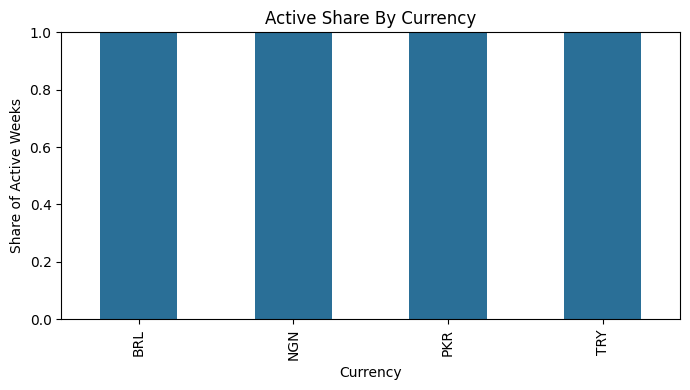

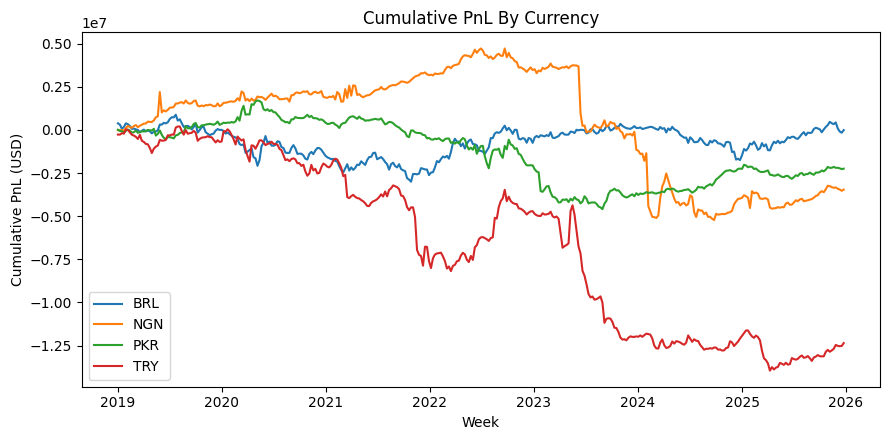

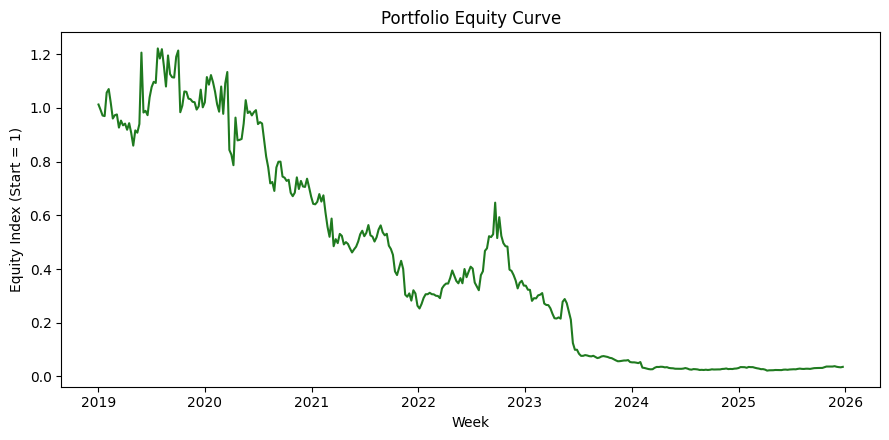

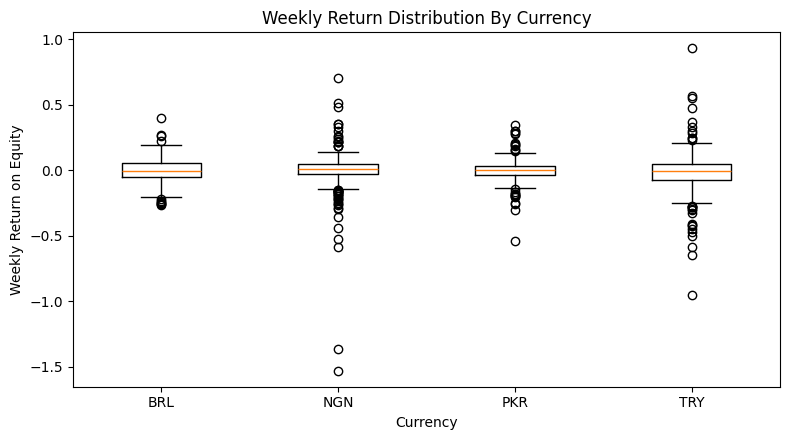

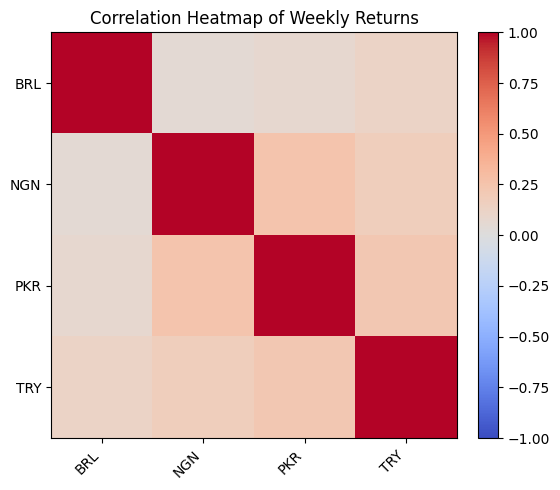

In [43]:
active_share = carry_weekly.groupby("currency")["active"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
active_share.plot(kind="bar", ax=ax, color="#2a6f97")
ax.set_title("Active Share By Currency")
ax.set_xlabel("Currency")
ax.set_ylabel("Share of Active Weeks")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

cum_pnl = carry_weekly.sort_values(["currency", "week_date"]).copy()
cum_pnl["cum_pnl_usd"] = cum_pnl.groupby("currency")["total_pnl_usd"].cumsum()

fig, ax = plt.subplots(figsize=(9, 4.5))
for ccy, g in cum_pnl.groupby("currency", sort=False):
    ax.plot(g["week_date"], g["cum_pnl_usd"], label=ccy)
ax.set_title("Cumulative PnL By Currency")
ax.set_xlabel("Week")
ax.set_ylabel("Cumulative PnL (USD)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(portfolio["week_date"], portfolio["equity_curve"], color="#1f7a1f")
ax.set_title("Portfolio Equity Curve")
ax.set_xlabel("Week")
ax.set_ylabel("Equity Index (Start = 1)")
plt.tight_layout()
plt.show()

box_data = [carry_weekly.loc[carry_weekly["currency"] == ccy, "ret_on_equity"].dropna().values for ccy in sorted(carry_weekly["currency"].unique())]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(box_data, labels=sorted(carry_weekly["currency"].unique()), showfliers=True)
ax.set_title("Weekly Return Distribution By Currency")
ax.set_xlabel("Currency")
ax.set_ylabel("Weekly Return on Equity")
plt.tight_layout()
plt.show()

corr = ret_corr.reindex(index=sorted(ret_corr.index), columns=sorted(ret_corr.columns))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap of Weekly Returns")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Active share is 1.00 for BRL, NGN, PKR, and TRY, so the spread filter did not deactivate positions in this sample. In this run, EM 5Y rates were consistently above the UK benchmark proxy on aligned entry weeks. That means the realized risk profile comes from curve repricing and FX moves rather than timing by the no-position rule.

Performance is weak in this sample. Annualized Sharpe is approximately -0.001 for BRL, -0.219 for NGN, -0.275 for PKR, and -0.809 for TRY. Portfolio Sharpe is about -0.603 and max drawdown is about -0.982. Return correlations are positive but moderate, with the largest pair around 0.24 (NGN-PKR), which limits diversification during stress.

Tail events are visible in both legs. The largest funding loss occurs near 2022-09-28 and is about -$593k, driven by a large GBPUSD move between entry and exit. The largest lending loss occurs near 2024-02-07 in NGN at about -$3.05MM, showing that local-curve and FX shocks can dominate weekly carry income.


## Limitations And Extensions

- Wednesday alignment within plus or minus two business days is a practical convention and can move entry levels for sparse markets.
- Day-count uses 7/365. A 7/360 convention would slightly change funding carry and may matter in close comparisons.
- The UK benchmark currently acts as a proxy input and can affect how often the no-position rule binds.
- Sparse EM tenor points require interpolation. Interpolation can misstate one-week repricing around stressed dates.
- Positive cross-currency correlation in this sample means diversification is limited when losses cluster.
- Market context matters: policy shifts, FX intervention, and liquidity shocks can create large weekly deviations from carry expectations.
- Implementation extensions that would improve robustness include quote freshness checks, transaction cost modeling, and regime-aware exposure sizing.


In [44]:
factor_df = weekly_panel.copy().sort_values(["currency", "week_date"])
em5 = factor_df.pivot_table(index="week_date", columns="currency", values="s5", aggfunc="mean").sort_index()
fxg = factor_df.pivot_table(index="week_date", columns="currency", values="usd_per_ccy", aggfunc="mean").sort_index()
ukf = factor_df.drop_duplicates("week_date").sort_values("week_date")[["week_date", "uk_ois_rate", "uk_5y_benchmark_rate"]].set_index("week_date")

factors = pd.DataFrame(index=em5.index)
factors["avg_em_5y_change_bp"] = em5.mean(axis=1).diff()
factors["usd_gbp_return"] = fxg["GBP"].pct_change() if "GBP" in fxg.columns else np.nan
factors["uk_ois_change_bp"] = ukf["uk_ois_rate"].reindex(factors.index).diff()

port = portfolio.set_index("week_date")["ret_on_equity"].reindex(factors.index)
fac_corr = pd.concat([port.rename("portfolio_ret_eq"), factors], axis=1).corr().loc["portfolio_ret_eq", factors.columns]

currency_factor_beta = []
for ccy in ret_matrix.columns:
    y = ret_matrix[ccy].reindex(factors.index)
    tmp = pd.concat([y.rename("y"), factors], axis=1).dropna()
    if tmp.empty:
        continue
    x = tmp[["avg_em_5y_change_bp", "usd_gbp_return", "uk_ois_change_bp"]].values
    yv = tmp["y"].values
    x = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(x, yv, rcond=None)[0]
    currency_factor_beta.append({
        "currency": ccy,
        "beta_const": float(beta[0]),
        "beta_em5": float(beta[1]),
        "beta_usd_gbp": float(beta[2]),
        "beta_uk_ois": float(beta[3]),
    })

if currency_factor_beta:
    factor_betas = pd.DataFrame(currency_factor_beta).sort_values("currency").reset_index(drop=True)
else:
    factor_betas = pd.DataFrame(columns=["currency", "beta_const", "beta_em5", "beta_usd_gbp", "beta_uk_ois"])

summary = {
    "portfolio_sharpe": float(portfolio_sharpe) if pd.notna(portfolio_sharpe) else np.nan,
    "portfolio_max_drawdown": float(portfolio_mdd) if pd.notna(portfolio_mdd) else np.nan,
}

summary, fac_corr, factor_betas


({'portfolio_sharpe': -0.6034780593223911,
  'portfolio_max_drawdown': -0.9821900160756915},
 avg_em_5y_change_bp   -0.111834
 usd_gbp_return              NaN
 uk_ois_change_bp      -0.081058
 Name: portfolio_ret_eq, dtype: float64,
 Empty DataFrame
 Columns: [currency, beta_const, beta_em5, beta_usd_gbp, beta_uk_ois]
 Index: [])

In [45]:
active_share_check = carry_weekly.groupby("currency")["active"].mean().sort_values(ascending=False)

fund_cols = [
    "week_date", "currency", "funding_pnl_usd", "gbp_usd_t", "gbp_usd_tp1",
    "gbp_principal", "gbp_interest", "gbp_ois_t_dec", "active"
]

lend_cols = [
    "week_date", "currency", "lending_pnl_usd", "s5_next", "usd_per_ccy_next",
    "bond_price_t", "bond_price_tp1", "pricing_mode", "carry_added_usd", "active"
]

largest_funding = carry_weekly.loc[carry_weekly["funding_pnl_usd"].abs().idxmax(), fund_cols]
largest_lending = carry_weekly.loc[carry_weekly["lending_pnl_usd"].abs().idxmax(), lend_cols]

active_share_check, largest_funding, largest_lending, currency_stats[["currency", "ann_sharpe"]], ret_corr.shape, ret_corr


(currency
 BRL    1.0
 NGN    1.0
 PKR    1.0
 TRY    1.0
 Name: active, dtype: float64,
 week_date          2022-09-28 00:00:00
 currency                           BRL
 funding_pnl_usd         -593107.406055
 gbp_usd_t                     1.064899
 gbp_usd_tp1                    1.14326
 gbp_principal                7512448.0
 gbp_interest               3874.303217
 gbp_ois_t_dec                 0.021891
 active                               1
 Name: 195, dtype: object,
 week_date           2024-02-07 00:00:00
 currency                            NGN
 lending_pnl_usd         -3053279.699736
 s5_next                       16.606821
 usd_per_ccy_next               0.000684
 bond_price_t                        1.0
 bond_price_tp1                 0.999519
 pricing_mode                      dirty
 carry_added_usd                     0.0
 active                                1
 Name: 631, dtype: object,
   currency  ann_sharpe
 0      BRL   -0.001261
 1      NGN   -0.218524
 2      PKR   -

## Conclusion

The pipeline is complete and auditable from data ingestion through weekly PnL attribution. In this run, the strategy is effectively always active and delivers negative risk-adjusted performance, with large downside episodes dominated by FX and repricing shocks. The next improvement step is to tighten benchmark specification and add implementation controls such as stale-quote filters, cost assumptions, and regime-aware risk limits.
